In [1]:
# Homework 1 Problem 3 - ResNet-11 vs ResNet-18 on CIFAR-10

import os, random, time, csv, json
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

seed = 42
epochs = 50
batch_size = 256
lr = 0.001
fast_cpu = True

if fast_cpu:
    train_size = 10000
    val_size = 2000
else:
    train_size = 45000
    val_size = 5000

random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device, 'train:', train_size, 'val:', val_size)

classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
os.makedirs('Data', exist_ok=True); os.makedirs('Results_P3', exist_ok=True)

mean = (0.4914, 0.4822, 0.4465); std = (0.2470, 0.2435, 0.2616)
train_tf = transforms.Compose([transforms.RandomHorizontalFlip(), transforms.ToTensor(), transforms.Normalize(mean,std)])
test_tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean,std)])

train_all_aug = torchvision.datasets.CIFAR10(root='Data', train=True, download=True, transform=train_tf)
train_all_plain = torchvision.datasets.CIFAR10(root='Data', train=True, download=True, transform=test_tf)
test_data = torchvision.datasets.CIFAR10(root='Data', train=False, download=True, transform=test_tf)

gen = torch.Generator().manual_seed(seed)
idx = torch.randperm(50000, generator=gen).tolist()
train_idx = idx[:train_size]
val_idx = idx[45000:45000+val_size]

train_data = Subset(train_all_aug, train_idx)
val_data = Subset(train_all_plain, val_idx)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=0)
print(len(train_data), len(val_data), len(test_data))

device: cpu train: 10000 val: 2000
10000 2000 10000


In [2]:
class BasicBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c, out_c, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_c)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_c)
        if stride != 1 or in_c != out_c:
            self.skip = nn.Sequential(nn.Conv2d(in_c, out_c, 1, stride=stride, bias=False), nn.BatchNorm2d(out_c))
        else:
            self.skip = nn.Identity()
    def forward(self, x):
        y = torch.relu(self.bn1(self.conv1(x)))
        y = self.bn2(self.conv2(y))
        y = y + self.skip(x)
        y = torch.relu(y)
        return y

class ResNet(nn.Module):
    def __init__(self, blocks, drop=0.0, width=16):
        super().__init__()
        # CIFAR-10 version: 3x3 first conv and no initial max pooling.
        self.in_c = width
        self.stem = nn.Sequential(nn.Conv2d(3, width, 3, padding=1, bias=False), nn.BatchNorm2d(width), nn.ReLU())
        self.layer1 = self.make_layer(width, blocks[0], 1)
        self.layer2 = self.make_layer(width*2, blocks[1], 2)
        self.layer3 = self.make_layer(width*4, blocks[2], 2)
        self.layer4 = self.make_layer(width*8, blocks[3], 2)
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        self.drop = nn.Dropout(drop)
        self.fc = nn.Linear(width*8, 10)
    def make_layer(self, out_c, n, stride):
        layers = [BasicBlock(self.in_c, out_c, stride)]
        self.in_c = out_c
        for i in range(1, n):
            layers.append(BasicBlock(out_c, out_c, 1))
        return nn.Sequential(*layers)
    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.drop(x)
        return self.fc(x)

def ResNet11(drop=0.0):
    return ResNet([1,1,1,2], drop, width=16)

def ResNet18(drop=0.0):
    return ResNet([2,2,2,2], drop, width=16)

def get_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print('ResNet11 params:', get_params(ResNet11()))
print('ResNet18 params:', get_params(ResNet18()))

ResNet11 params: 604250
ResNet18 params: 701466


In [3]:
def eval_model(model, loader):
    model.eval(); loss_fn=nn.CrossEntropyLoss(); total_loss=0; correct=0; total=0; ytrue=[]; ypred=[]
    with torch.no_grad():
        for x,y in loader:
            x=x.to(device); y=y.to(device); out=model(x); loss=loss_fn(out,y)
            total_loss += loss.item()*x.size(0); pred=out.argmax(1); correct += (pred==y).sum().item(); total += y.size(0)
            ytrue += list(y.cpu().numpy()); ypred += list(pred.cpu().numpy())
    return total_loss/total, correct/total, ytrue, ypred

def train_model(name, which, drop):
    print('\nRUNNING:', name)
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    folder = 'Results_P3/' + name; os.makedirs(folder, exist_ok=True)
    model = ResNet11(drop).to(device) if which == 'r11' else ResNet18(drop).to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4, min_lr=1e-5)
    tl=[]; vl=[]; ta=[]; va=[]; best=0; start=time.time()
    for e in range(epochs):
        model.train(); total_loss=0; total_correct=0; total_seen=0
        for x,y in train_loader:
            x=x.to(device); y=y.to(device); optimizer.zero_grad(); out=model(x); loss=loss_fn(out,y); loss.backward(); optimizer.step()
            total_loss += loss.item()*x.size(0); pred=out.argmax(1); total_correct += (pred==y).sum().item(); total_seen += y.size(0)
        tr_loss=total_loss/total_seen; tr_acc=total_correct/total_seen; va_loss,va_acc,a,b=eval_model(model,val_loader); scheduler.step(va_loss)
        tl.append(tr_loss); vl.append(va_loss); ta.append(tr_acc); va.append(va_acc)
        if va_acc > best:
            best = va_acc; torch.save(model.state_dict(), folder + '/best_model.pth')
        print(e+1, 'train loss', round(tr_loss,4), 'train acc', round(tr_acc,4), 'val loss', round(va_loss,4), 'val acc', round(va_acc,4))
    model.load_state_dict(torch.load(folder + '/best_model.pth', map_location=device))
    te_loss, te_acc, ytrue, ypred = eval_model(model, test_loader); elapsed=time.time()-start
    print('test acc =', te_acc, 'best val =', best, 'time =', elapsed)
    info = {'seed':seed,'epochs':epochs,'train_size':train_size,'val_size':val_size,'batch_size':batch_size,'model':which,'dropout':drop,'params':get_params(model),'test_acc':te_acc,'best_val_acc':best,'time':elapsed,'hardware':torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}
    json.dump(info, open(folder + '/results.json','w'), indent=4)
    with open(folder + '/metrics.csv','w',newline='') as f:
        w=csv.writer(f); w.writerow(['epoch','train_loss','val_loss','train_acc','val_acc'])
        for i in range(epochs): w.writerow([i+1,tl[i],vl[i],ta[i],va[i]])
    plt.figure(figsize=(7,5)); plt.plot(tl,label='train loss'); plt.plot(vl,label='val loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title(name+' loss'); plt.legend(); plt.grid(); plt.savefig(folder+'/loss.png',dpi=200); plt.show()
    plt.figure(figsize=(7,5)); plt.plot(ta,label='train acc'); plt.plot(va,label='val acc'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title(name+' accuracy'); plt.legend(); plt.grid(); plt.savefig(folder+'/accuracy.png',dpi=200); plt.show()
    cm=confusion_matrix(ytrue,ypred); disp=ConfusionMatrixDisplay(cm,display_labels=classes); fig,ax=plt.subplots(figsize=(10,8)); disp.plot(ax=ax,xticks_rotation=45,cmap='Blues'); plt.title(name+' confusion matrix'); plt.savefig(folder+'/confusion_matrix.png',dpi=200,bbox_inches='tight'); plt.show()
    return model, tl, vl, ta, va, info


RUNNING: resnet11_baseline
1 train loss 1.7129 train acc 0.3592 val loss 1.5357 val acc 0.446
2 train loss 1.3887 train acc 0.483 val loss 1.7447 val acc 0.3845
3 train loss 1.2338 train acc 0.5504 val loss 1.31 val acc 0.514
4 train loss 1.1262 train acc 0.5956 val loss 1.2955 val acc 0.536
5 train loss 0.989 train acc 0.6493 val loss 1.2725 val acc 0.557
6 train loss 0.9205 train acc 0.6717 val loss 1.3494 val acc 0.524
7 train loss 0.8236 train acc 0.7048 val loss 1.535 val acc 0.5105
8 train loss 0.7513 train acc 0.7434 val loss 1.7215 val acc 0.4815
9 train loss 0.6913 train acc 0.7583 val loss 1.2049 val acc 0.5835
10 train loss 0.6482 train acc 0.772 val loss 1.3862 val acc 0.551
11 train loss 0.5437 train acc 0.8152 val loss 1.4522 val acc 0.562
12 train loss 0.5401 train acc 0.8129 val loss 1.4071 val acc 0.5705
13 train loss 0.4541 train acc 0.846 val loss 1.3213 val acc 0.592
14 train loss 0.3903 train acc 0.8702 val loss 1.3159 val acc 0.5905
15 train loss 0.2633 train acc

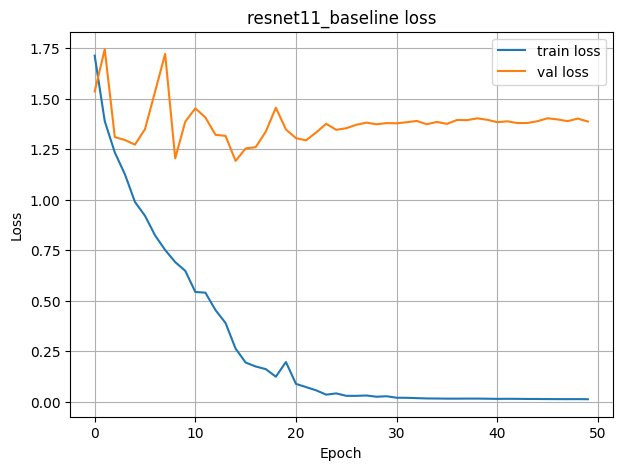

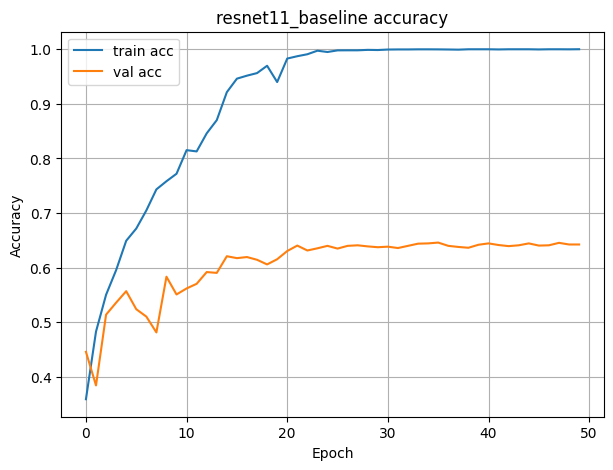

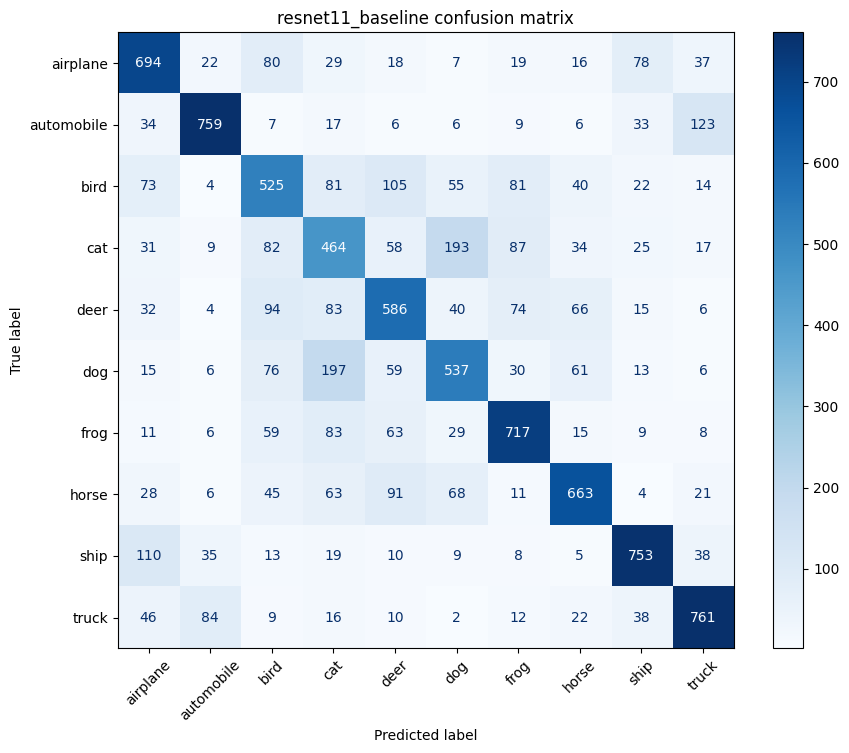


RUNNING: resnet18_baseline
1 train loss 1.7341 train acc 0.3587 val loss 1.821 val acc 0.3525
2 train loss 1.4349 train acc 0.4711 val loss 1.5036 val acc 0.4575
3 train loss 1.2522 train acc 0.5408 val loss 1.4195 val acc 0.483
4 train loss 1.1669 train acc 0.5796 val loss 1.463 val acc 0.491
5 train loss 1.0227 train acc 0.6358 val loss 1.3161 val acc 0.5535
6 train loss 0.9087 train acc 0.6761 val loss 1.1976 val acc 0.588
7 train loss 0.8425 train acc 0.6997 val loss 1.2547 val acc 0.568
8 train loss 0.772 train acc 0.7279 val loss 1.1731 val acc 0.6005
9 train loss 0.7086 train acc 0.751 val loss 1.1256 val acc 0.6135
10 train loss 0.5993 train acc 0.7892 val loss 1.0978 val acc 0.6175
11 train loss 0.6059 train acc 0.7862 val loss 1.2049 val acc 0.6165
12 train loss 0.4953 train acc 0.8311 val loss 1.2572 val acc 0.596
13 train loss 0.4441 train acc 0.8513 val loss 1.3231 val acc 0.6015
14 train loss 0.4141 train acc 0.8617 val loss 1.1321 val acc 0.642
15 train loss 0.3257 trai

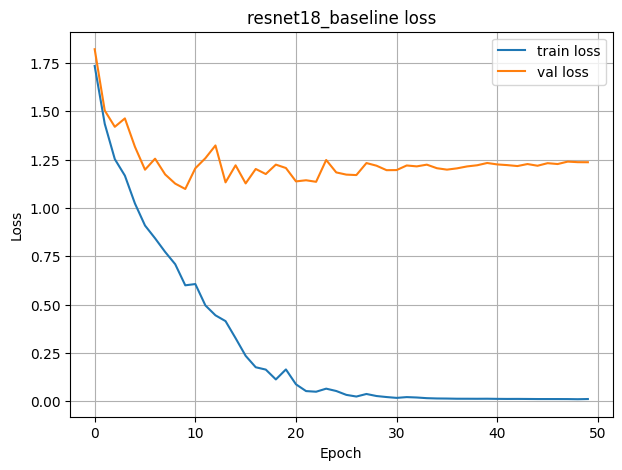

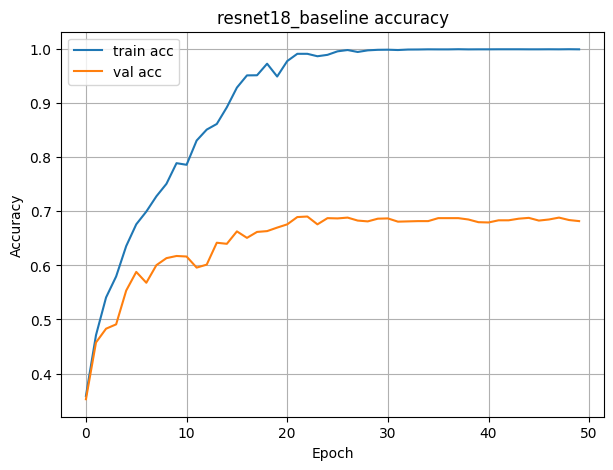

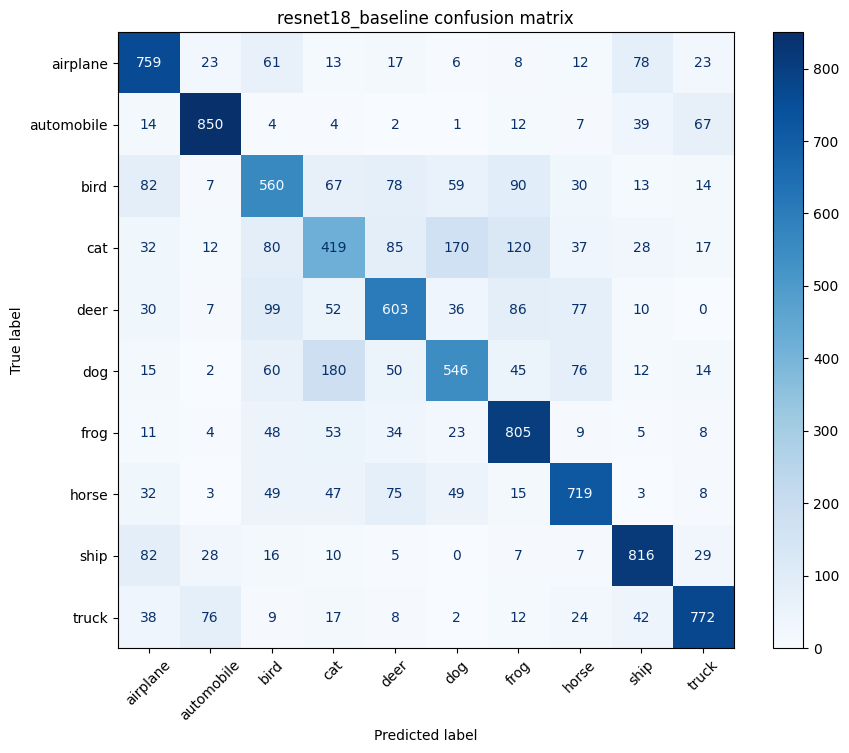


RUNNING: resnet11_dropout_03
1 train loss 1.7959 train acc 0.329 val loss 1.9525 val acc 0.3325
2 train loss 1.4731 train acc 0.4576 val loss 1.6851 val acc 0.3915
3 train loss 1.3142 train acc 0.5243 val loss 1.4388 val acc 0.4885
4 train loss 1.1654 train acc 0.5764 val loss 1.4304 val acc 0.4875
5 train loss 1.082 train acc 0.6174 val loss 1.3522 val acc 0.5215
6 train loss 0.9964 train acc 0.6463 val loss 1.3843 val acc 0.5095
7 train loss 0.9332 train acc 0.6732 val loss 1.2538 val acc 0.5605
8 train loss 0.8639 train acc 0.6986 val loss 1.5014 val acc 0.5075
9 train loss 0.8004 train acc 0.7203 val loss 1.4328 val acc 0.536
10 train loss 0.7128 train acc 0.7552 val loss 1.3586 val acc 0.541
11 train loss 0.6662 train acc 0.7704 val loss 1.3211 val acc 0.572
12 train loss 0.6101 train acc 0.7878 val loss 1.2404 val acc 0.594
13 train loss 0.5563 train acc 0.8104 val loss 1.2736 val acc 0.6
14 train loss 0.5117 train acc 0.8323 val loss 1.3853 val acc 0.571
15 train loss 0.5398 tr

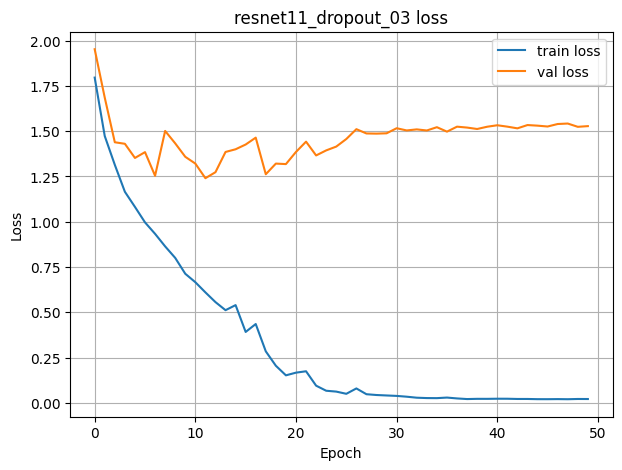

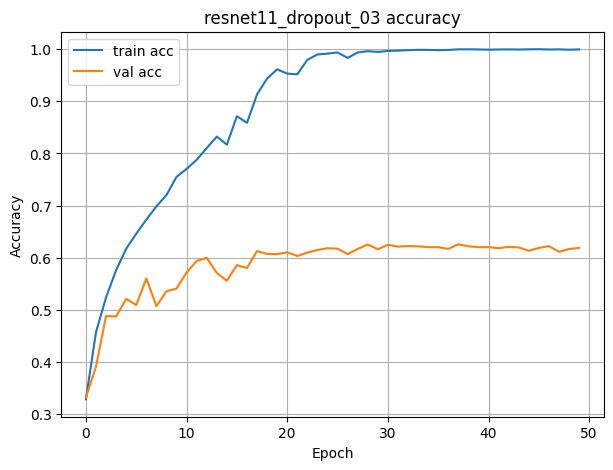

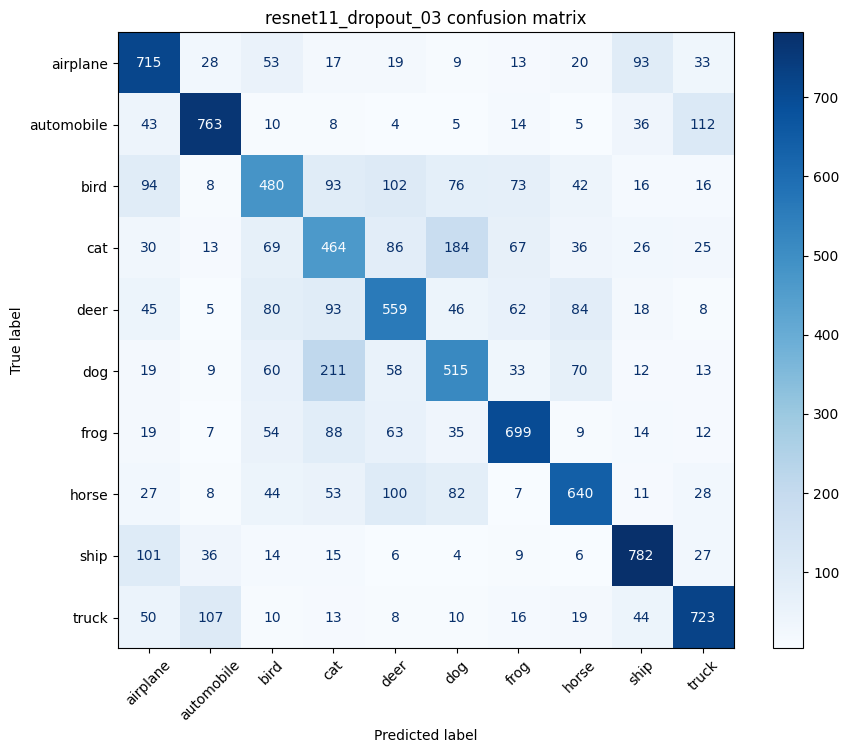


RUNNING: resnet11_dropout_05
1 train loss 1.8723 train acc 0.3033 val loss 1.7586 val acc 0.3745
2 train loss 1.5263 train acc 0.4372 val loss 1.6273 val acc 0.4025
3 train loss 1.3701 train acc 0.4995 val loss 1.4806 val acc 0.4685
4 train loss 1.2105 train acc 0.5616 val loss 1.5089 val acc 0.4955
5 train loss 1.1287 train acc 0.5976 val loss 1.2829 val acc 0.5425
6 train loss 1.0579 train acc 0.6221 val loss 1.2324 val acc 0.5655
7 train loss 0.986 train acc 0.6548 val loss 1.2728 val acc 0.553
8 train loss 0.9301 train acc 0.6744 val loss 1.2932 val acc 0.5625
9 train loss 0.8565 train acc 0.6992 val loss 1.4389 val acc 0.52
10 train loss 0.7811 train acc 0.7291 val loss 1.1688 val acc 0.602
11 train loss 0.7268 train acc 0.7533 val loss 1.4307 val acc 0.5345
12 train loss 0.6619 train acc 0.7748 val loss 1.3923 val acc 0.565
13 train loss 0.6478 train acc 0.78 val loss 1.2604 val acc 0.596
14 train loss 0.6182 train acc 0.7918 val loss 1.2456 val acc 0.594
15 train loss 0.5668 tr

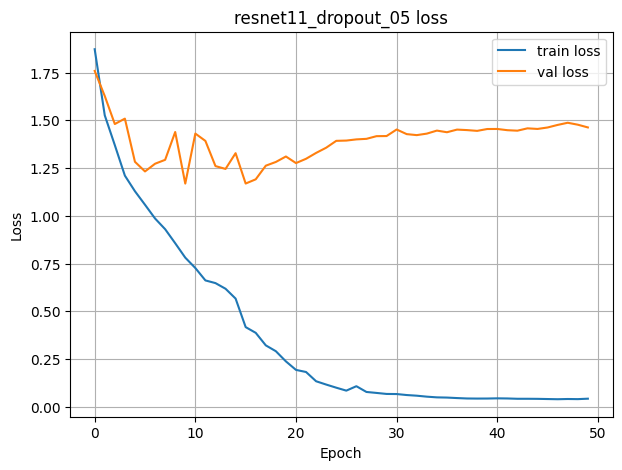

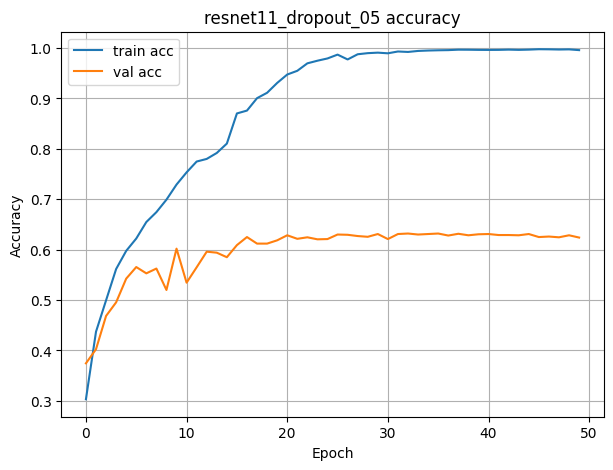

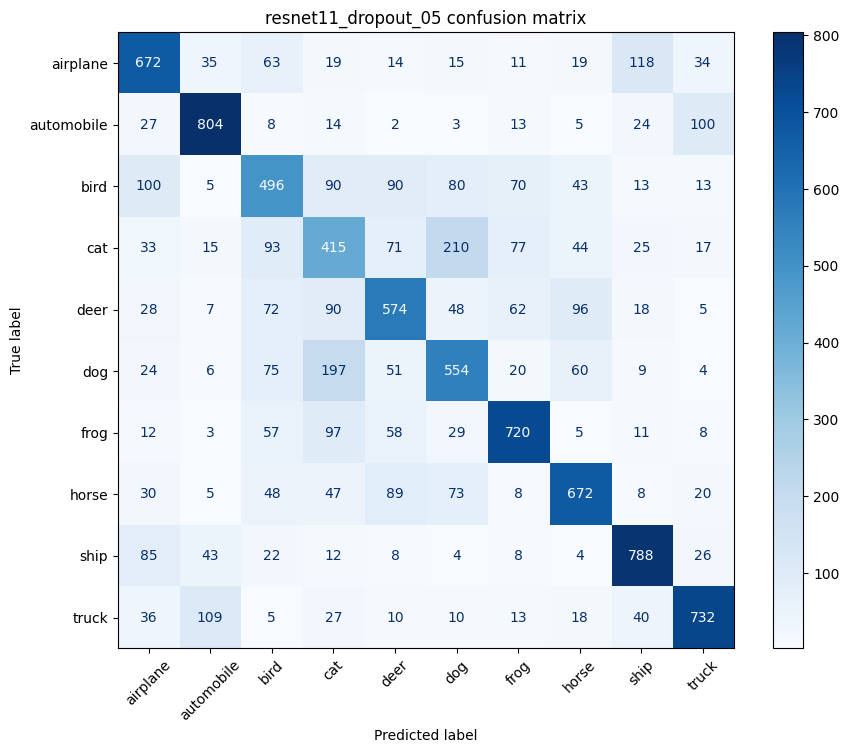


RUNNING: resnet18_dropout_03
1 train loss 1.7985 train acc 0.3341 val loss 1.6286 val acc 0.405
2 train loss 1.5009 train acc 0.4438 val loss 1.5955 val acc 0.4395
3 train loss 1.351 train acc 0.5064 val loss 1.767 val acc 0.411
4 train loss 1.2545 train acc 0.547 val loss 1.2944 val acc 0.5305
5 train loss 1.0958 train acc 0.6033 val loss 1.2612 val acc 0.5475
6 train loss 1.0455 train acc 0.6298 val loss 1.3755 val acc 0.5325
7 train loss 0.9718 train acc 0.6546 val loss 1.5357 val acc 0.4845
8 train loss 0.9026 train acc 0.6832 val loss 1.2828 val acc 0.5625
9 train loss 0.8411 train acc 0.7029 val loss 1.416 val acc 0.534
10 train loss 0.7614 train acc 0.736 val loss 1.1846 val acc 0.595
11 train loss 0.6718 train acc 0.7679 val loss 1.3922 val acc 0.5395
12 train loss 0.6989 train acc 0.757 val loss 1.371 val acc 0.565
13 train loss 0.6218 train acc 0.7866 val loss 1.1757 val acc 0.615
14 train loss 0.5973 train acc 0.7925 val loss 1.3196 val acc 0.571
15 train loss 0.5619 train 

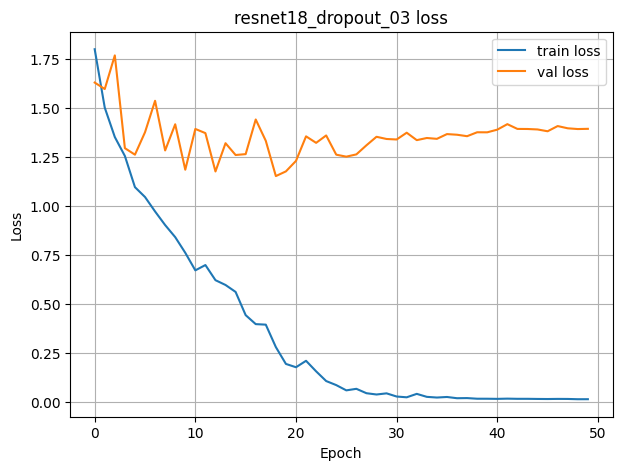

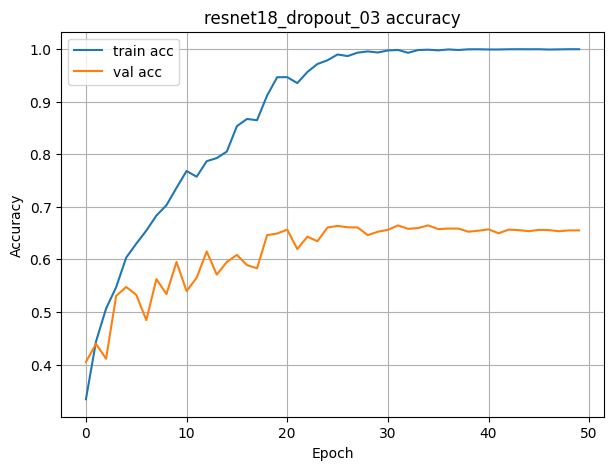

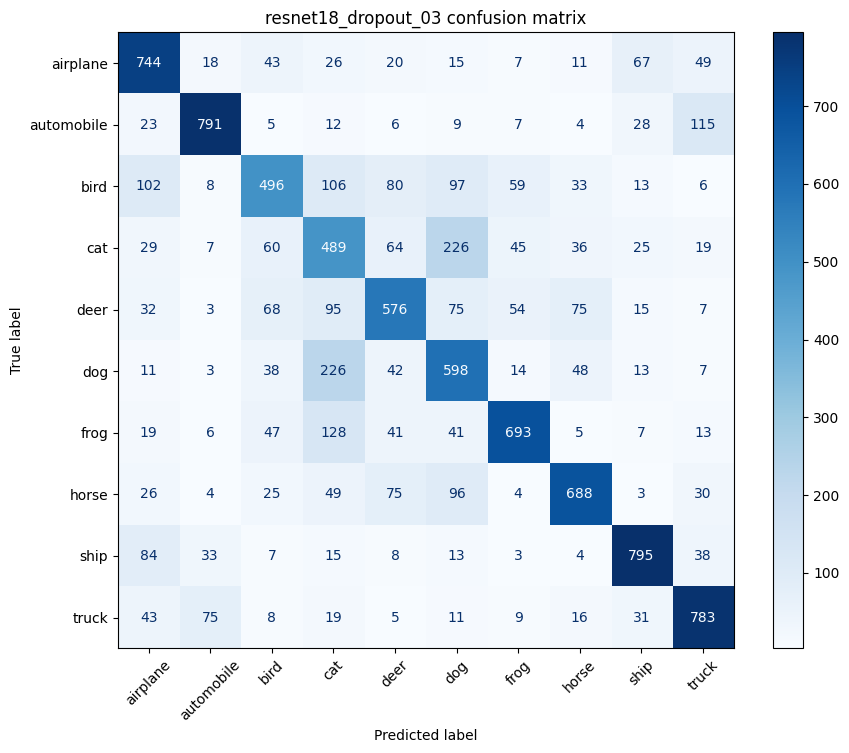


RUNNING: resnet18_dropout_05
1 train loss 1.8769 train acc 0.3054 val loss 1.6865 val acc 0.369
2 train loss 1.5778 train acc 0.4214 val loss 1.7023 val acc 0.388
3 train loss 1.4164 train acc 0.4855 val loss 1.5359 val acc 0.4435
4 train loss 1.3021 train acc 0.527 val loss 1.5051 val acc 0.466
5 train loss 1.1899 train acc 0.5741 val loss 1.3118 val acc 0.519
6 train loss 1.0965 train acc 0.6115 val loss 1.4486 val acc 0.502
7 train loss 1.0201 train acc 0.645 val loss 1.2236 val acc 0.568
8 train loss 0.9714 train acc 0.658 val loss 1.2392 val acc 0.564
9 train loss 0.8907 train acc 0.6924 val loss 1.2959 val acc 0.5345
10 train loss 0.8193 train acc 0.7188 val loss 1.1831 val acc 0.5905
11 train loss 0.7518 train acc 0.7441 val loss 1.2952 val acc 0.556
12 train loss 0.7708 train acc 0.7376 val loss 1.2664 val acc 0.592
13 train loss 0.6687 train acc 0.7727 val loss 1.2344 val acc 0.5925
14 train loss 0.6121 train acc 0.7924 val loss 1.2412 val acc 0.616
15 train loss 0.5432 train

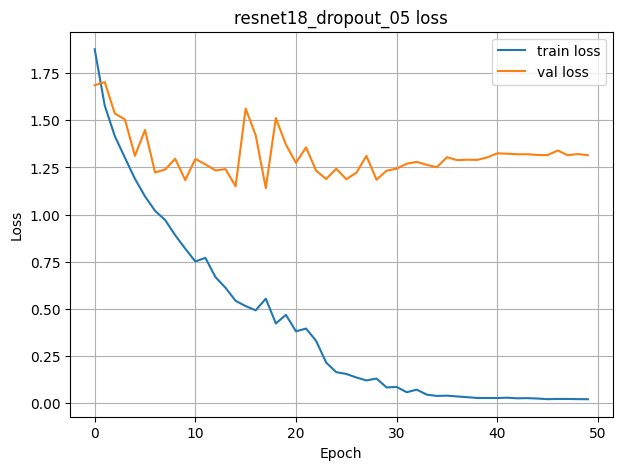

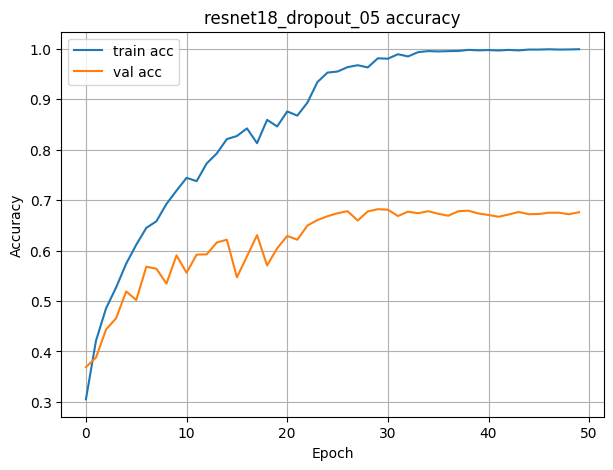

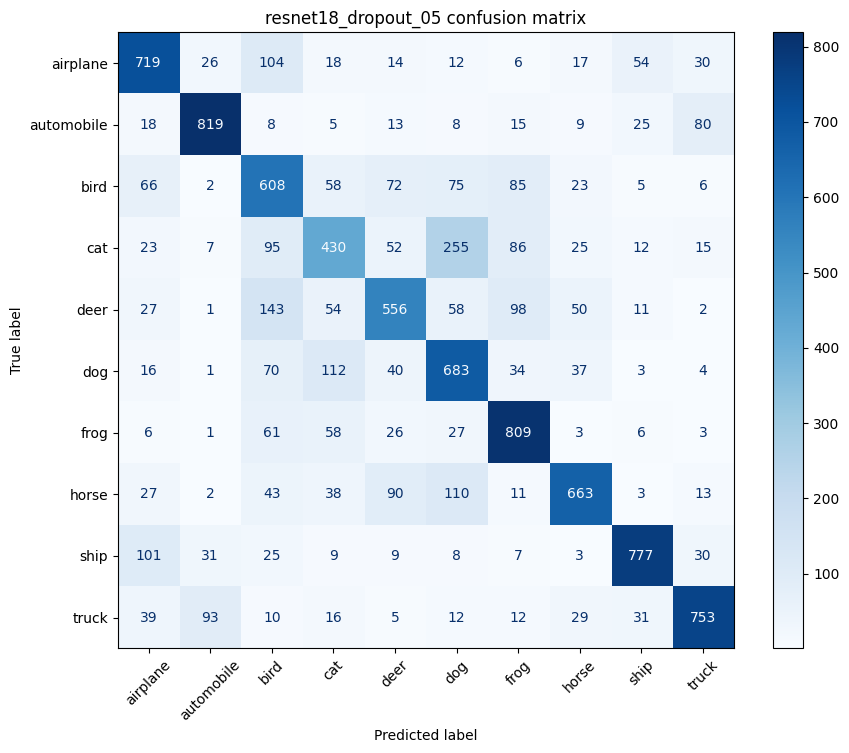

In [4]:
r11_model, r11_tl, r11_vl, r11_ta, r11_va, r11_info = train_model('resnet11_baseline', 'r11', 0.0)
r18_model, r18_tl, r18_vl, r18_ta, r18_va, r18_info = train_model('resnet18_baseline', 'r18', 0.0)
r11d03_model, r11d03_tl, r11d03_vl, r11d03_ta, r11d03_va, r11d03_info = train_model('resnet11_dropout_03', 'r11', 0.3)
r11d05_model, r11d05_tl, r11d05_vl, r11d05_ta, r11d05_va, r11d05_info = train_model('resnet11_dropout_05', 'r11', 0.5)
r18d03_model, r18d03_tl, r18d03_vl, r18d03_ta, r18d03_va, r18d03_info = train_model('resnet18_dropout_03', 'r18', 0.3)
r18d05_model, r18d05_tl, r18d05_vl, r18d05_ta, r18d05_va, r18d05_info = train_model('resnet18_dropout_05', 'r18', 0.5)

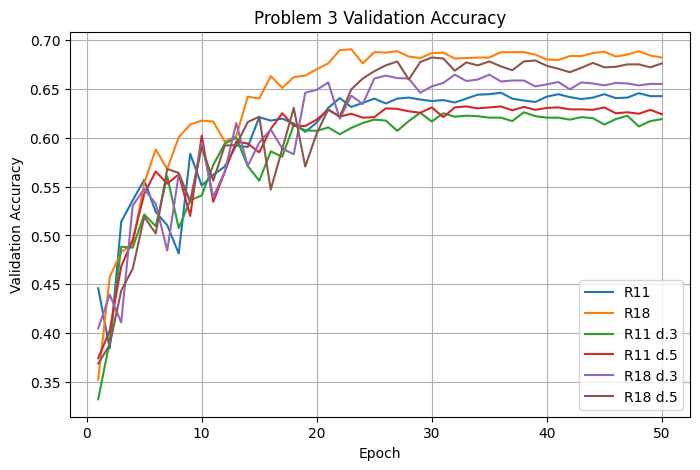

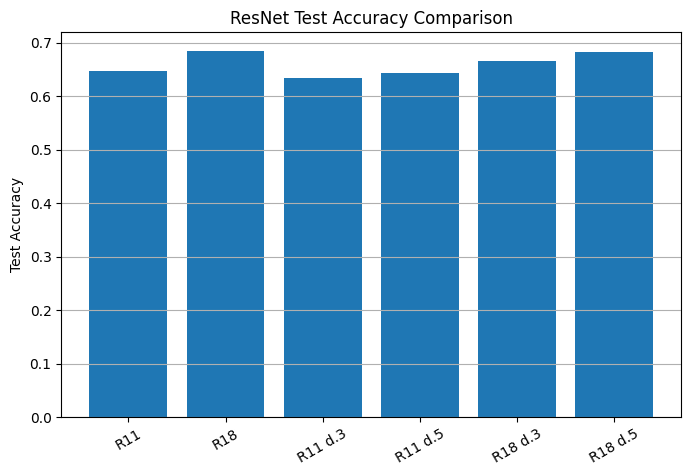

{'seed': 42, 'epochs': 50, 'train_size': 10000, 'val_size': 2000, 'batch_size': 256, 'model': 'r11', 'dropout': 0.0, 'params': 604250, 'test_acc': 0.6459, 'best_val_acc': 0.646, 'time': 3732.1824634075165, 'hardware': 'CPU'}
{'seed': 42, 'epochs': 50, 'train_size': 10000, 'val_size': 2000, 'batch_size': 256, 'model': 'r18', 'dropout': 0.0, 'params': 701466, 'test_acc': 0.6849, 'best_val_acc': 0.6905, 'time': 5880.863466978073, 'hardware': 'CPU'}
{'seed': 42, 'epochs': 50, 'train_size': 10000, 'val_size': 2000, 'batch_size': 256, 'model': 'r11', 'dropout': 0.3, 'params': 604250, 'test_acc': 0.634, 'best_val_acc': 0.626, 'time': 2008.1605291366577, 'hardware': 'CPU'}
{'seed': 42, 'epochs': 50, 'train_size': 10000, 'val_size': 2000, 'batch_size': 256, 'model': 'r11', 'dropout': 0.5, 'params': 604250, 'test_acc': 0.6427, 'best_val_acc': 0.632, 'time': 2700.5081753730774, 'hardware': 'CPU'}
{'seed': 42, 'epochs': 50, 'train_size': 10000, 'val_size': 2000, 'batch_size': 256, 'model': 'r18', 

In [5]:
x=range(1,epochs+1)
plt.figure(figsize=(8,5)); plt.plot(x,r11_va,label='R11'); plt.plot(x,r18_va,label='R18'); plt.plot(x,r11d03_va,label='R11 d.3'); plt.plot(x,r11d05_va,label='R11 d.5'); plt.plot(x,r18d03_va,label='R18 d.3'); plt.plot(x,r18d05_va,label='R18 d.5'); plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy'); plt.title('Problem 3 Validation Accuracy'); plt.legend(); plt.grid(); plt.savefig('Results_P3/val_acc_compare.png',dpi=200); plt.show()
names=['R11','R18','R11 d.3','R11 d.5','R18 d.3','R18 d.5']
accs=[r11_info['test_acc'],r18_info['test_acc'],r11d03_info['test_acc'],r11d05_info['test_acc'],r18d03_info['test_acc'],r18d05_info['test_acc']]
plt.figure(figsize=(8,5)); plt.bar(names, accs); plt.ylabel('Test Accuracy'); plt.title('ResNet Test Accuracy Comparison'); plt.xticks(rotation=30); plt.grid(axis='y'); plt.savefig('Results_P3/test_acc_bar.png',dpi=200,bbox_inches='tight'); plt.show()
print(r11_info); print(r18_info); print(r11d03_info); print(r11d05_info); print(r18d03_info); print(r18d05_info)
print('Report note: ResNet skip connections add the block input to the block output, which helps deeper models train.')